In [1]:
import pandas as pd

df = pd.read_csv("../data/netflix_cleaned.csv")

movies_df = df[df['type'] == "Movie"].copy()
tv_df = df[df['type'] == "TV Show"].copy()

# Prepare for country analysis
country_df = df[['primary_country', 'type', 'primary_genre', 'duration_num']].copy()

# Prepare for genre analysis
genre_df = df[['primary_genre', 'type']].copy()

print("Movies:", movies_df.shape)
print("TV Shows:", tv_df.shape)
print("Country Frame:", country_df.shape)
print("Genre Frame:", genre_df.shape)

df.head()


Movies: (6131, 22)
TV Shows: (2676, 22)
Country Frame: (8807, 4)
Genre Frame: (8807, 2)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,date_added_parsed,year_added,month_added,month_name_added,date_added_clean,duration_num,duration_type,primary_genre,country_clean,primary_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,...,2021-09-25,2021.0,9.0,September,"September 25, 2021",90.0,minutes,Documentaries,United States,United States
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,2021-09-24,2021.0,9.0,September,"September 24, 2021",2.0,seasons,International TV Shows,South Africa,South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,2021-09-24,2021.0,9.0,September,"September 24, 2021",1.0,seasons,Crime TV Shows,NaN,Unknown
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,2021-09-24,2021.0,9.0,September,"September 24, 2021",1.0,seasons,Docuseries,NaN,Unknown
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,2021-09-24,2021.0,9.0,September,"September 24, 2021",2.0,seasons,International TV Shows,India,India


In [2]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', '74 min', '84 min', '66 min', 'NR',
       'Unknown', 'TV-Y7-FV', 'UR'], dtype=object)

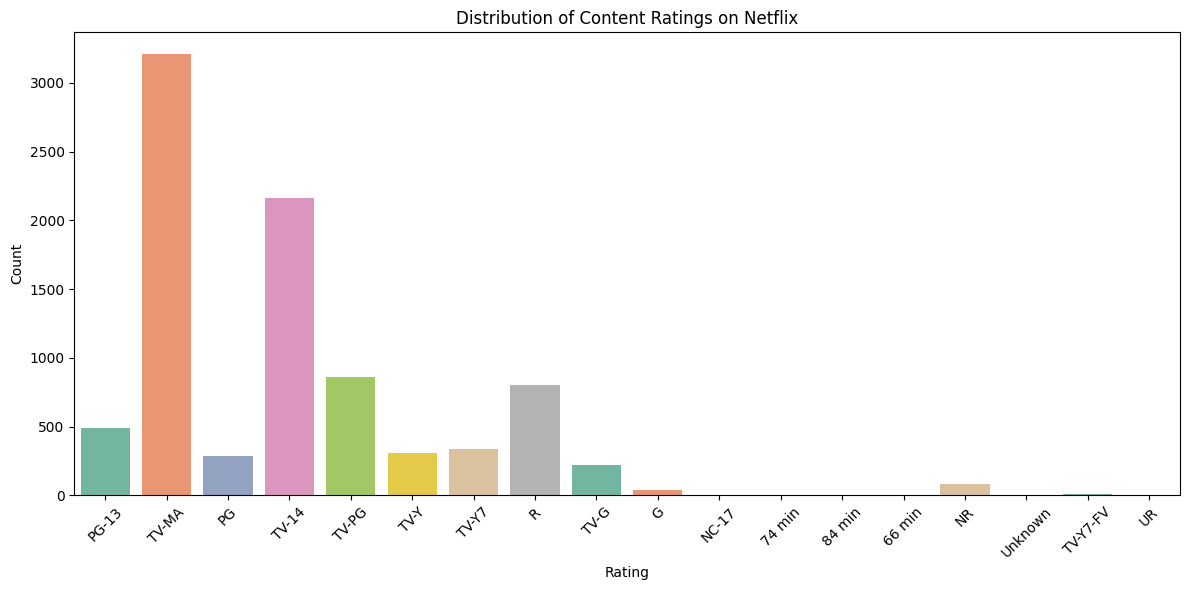

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.countplot(
    data=df,
    x='rating',
    hue='rating',       
    palette='Set2',
    legend=False
)

plt.title("Distribution of Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/rating_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


In [5]:
genre_type = df.pivot_table(
    index='primary_genre',
    columns='type',
    values='show_id',   
    aggfunc='count',
    fill_value=0
)

genre_type.head()

type,Movie,TV Show
primary_genre,,
Action & Adventure,859,0
Anime Features,21,0
Anime Series,0,176
British TV Shows,0,253
Children & Family Movies,605,0


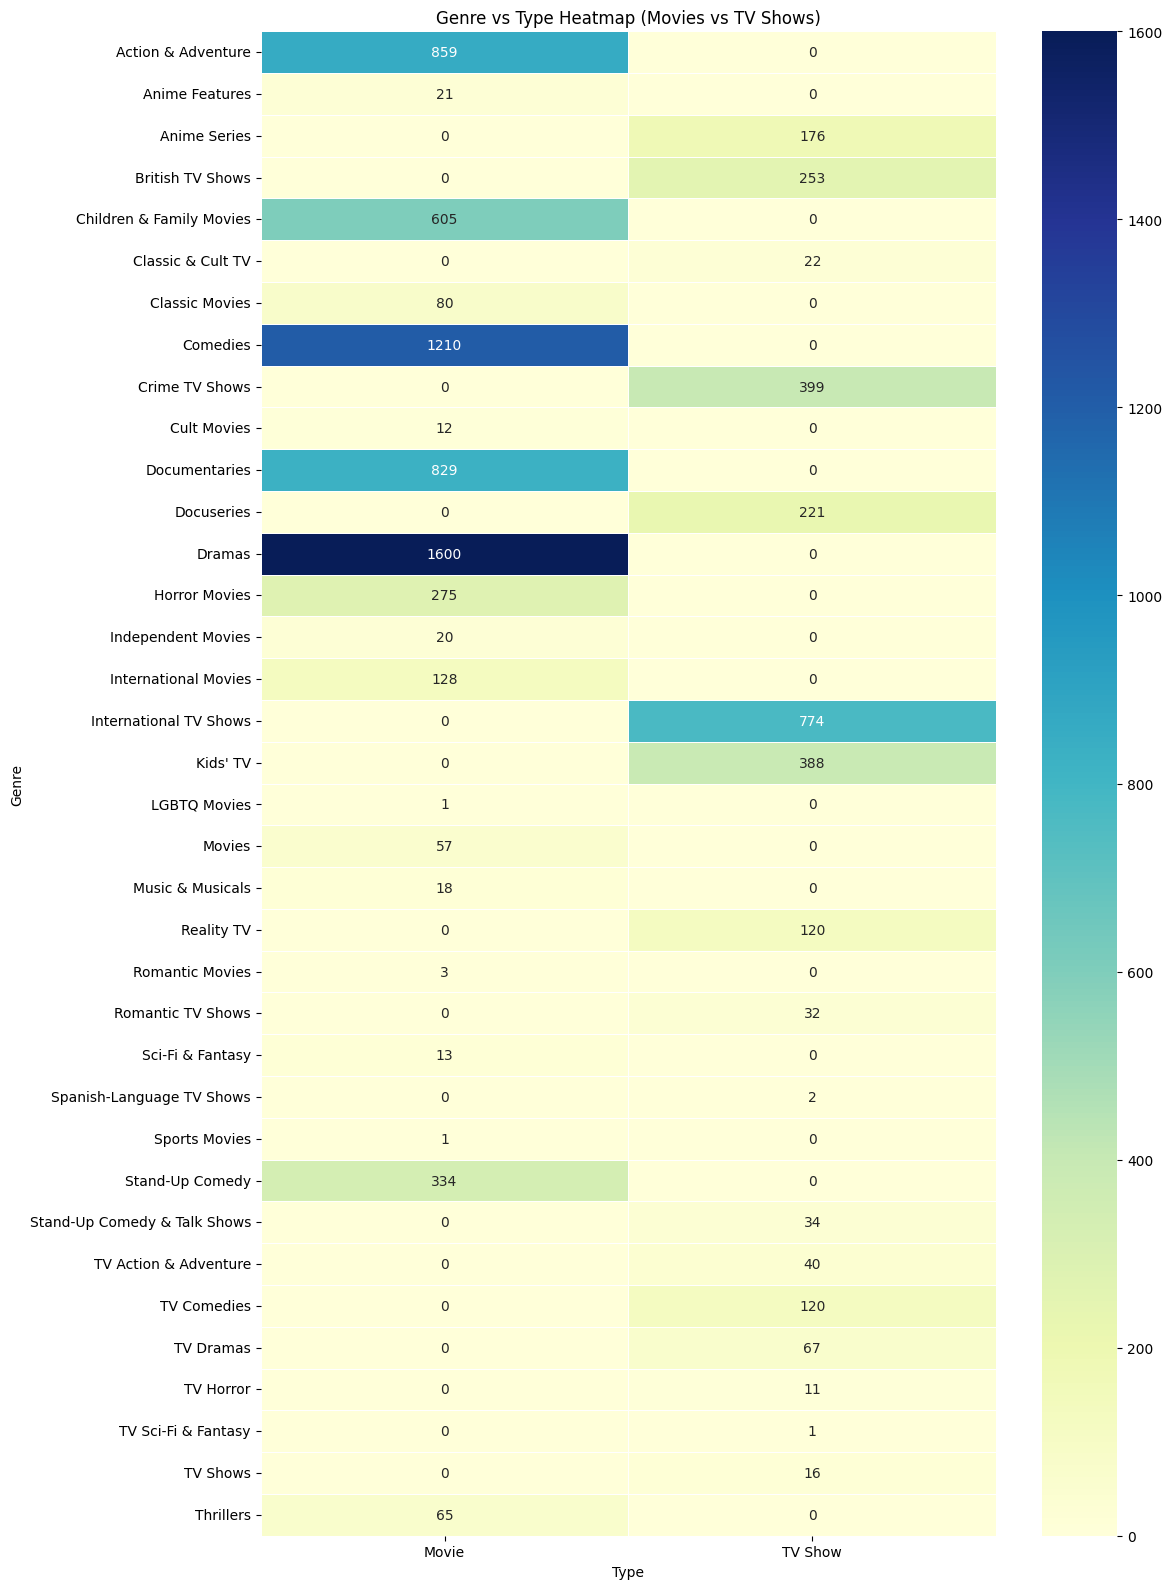

In [7]:
plt.figure(figsize=(12, 16))
sns.heatmap(
    genre_type,
    cmap='YlGnBu',
    linewidths=0.5,
    annot=True,
    fmt='d'
)

plt.title("Genre vs Type Heatmap (Movies vs TV Shows)")
plt.xlabel("Type")
plt.ylabel("Genre")
plt.tight_layout()
plt.savefig("../visuals/genre_vs_type_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
country_type = df.pivot_table(
    index='primary_country',
    columns='type',
    values='show_id',
    aggfunc='count',
    fill_value=0
)
country_type.head(15)

type,Movie,TV Show
primary_country,,
Argentina,56,20
Australia,61,56
Austria,8,1
Bangladesh,3,0
Belarus,0,1
Belgium,9,9
Brazil,56,28
Bulgaria,5,0
Cambodia,2,0


In [10]:
top15_country_type = country_type.sort_values("Movie", ascending=False).head(15)
top15_country_type

type,Movie,TV Show
primary_country,,
United States,2364,847
India,927,81
Unknown,440,391
United Kingdom,382,246
Canada,187,84
France,148,64
Spain,129,52
Egypt,98,14
Nigeria,87,9


<Figure size 1200x800 with 0 Axes>

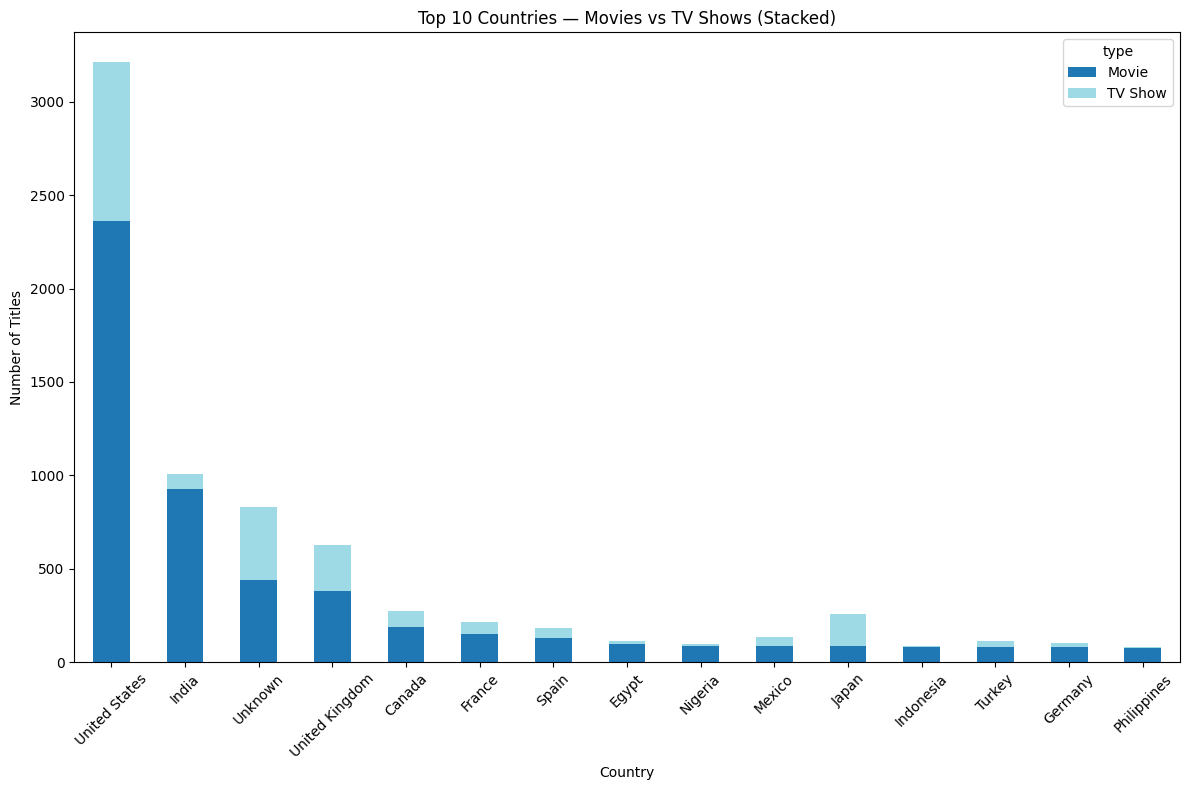

In [12]:
plt.figure(figsize=(12, 8))

top15_country_type.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 8),
    colormap='tab20'
)

plt.title("Top 10 Countries — Movies vs TV Shows (Stacked)")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../visuals/country_vs_type_stacked.png", dpi=300, bbox_inches='tight')
plt.show()

In [13]:
duration_compare = pd.DataFrame({
    "type": df["type"],
    "duration": df["duration_num"]
})

duration_compare = duration_compare.dropna()
duration_compare.head()

,type,duration
0,Movie,90.0
1,TV Show,2.0
2,TV Show,1.0
3,TV Show,1.0
4,TV Show,2.0


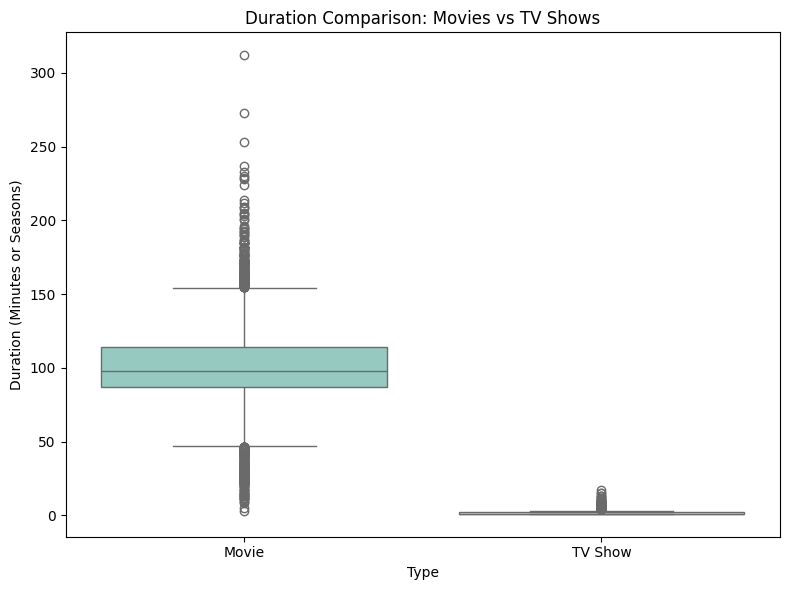

In [18]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=duration_compare,
    x='type',
    y='duration',
    hue='type',        
    palette='Set3',   
    legend=False      
)

plt.title("Duration Comparison: Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Duration (Minutes or Seasons)")
plt.tight_layout()
plt.savefig("../visuals/duration_comparison_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

In [19]:
agg_by_genre = (
    df.groupby(['primary_genre', 'type'])
      .size()
      .reset_index(name='count')
)

agg_by_genre.to_csv("../data/agg_by_genre.csv", index=False)
agg_by_genre.head()

,primary_genre,type,count
0,Action & Adventure,Movie,859
1,Anime Features,Movie,21
2,Anime Series,TV Show,176
3,British TV Shows,TV Show,253
4,Children & Family Movies,Movie,605


In [20]:
agg_by_country = (
    df.groupby(['primary_country', 'type'])
      .size()
      .reset_index(name='count')
)

agg_by_country.to_csv("../data/agg_by_country.csv", index=False)
agg_by_country.head()

,primary_country,type,count
0,Argentina,Movie,56
1,Argentina,TV Show,20
2,Australia,Movie,61
3,Australia,TV Show,56
4,Austria,Movie,8


In [21]:
agg_by_type = (
    df['type']
      .value_counts()
      .reset_index()
      .rename(columns={'index':'type', 'type':'count'})
)

agg_by_type.to_csv("../data/agg_by_type.csv", index=False)
agg_by_type

,count,count
0,Movie,6131
1,TV Show,2676


In [22]:
duration_stats = (
    df.groupby('type')['duration_num']
      .describe()
      .reset_index()
)

duration_stats.to_csv("../data/duration_stats.csv", index=False)
duration_stats

,type,count,mean,std,min,25%,50%,75%,max
0,Movie,6128.0,99.577187,28.290593,3.0,87.0,98.0,114.0,312.0
1,TV Show,2676.0,1.764948,1.582752,1.0,1.0,1.0,2.0,17.0
